# Dependencies & Environment Setup

In [ ]:
# 1. Install libraries
!pip install ultralytics gfpgan basicsr facexlib

# 2. Fix the torchvision error in basicsr
import os
!sed -i "s/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g" /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py
!sed -i "s/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g" /usr/local/lib/python3.12/dist-packages/basicsr/metrics/niqe.py
!sed -i "s/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g" /usr/local/lib/python3.12/dist-packages/basicsr/utils/img_util.py

import cv2
import numpy as np
import torch
import pandas as pd
from google.colab.patches import cv2_imshow
print("[CELL 1] Dependencies installed and environment fixed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 18.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 26.0 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214818 sha256=fa54064accd60ba6ed6eabc5ae18958e0dcbdedb67f34316b2f383775a094dd5
  Stored in directory: /root/.cache/pip/wheels/9a/

**Load YOLO & GAN Models**

In [ ]:
from ultralytics import YOLO
from gfpgan import GFPGANer

# Load YOLOv8-Face (Surveillance Model)
try:
    detector = YOLO('yolov8n-face.pt')
except:
    detector = YOLO('yolov8n.pt')

# Load GFPGAN (Defense Purifier)
model_path = 'https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth'
purifier = GFPGANer(model_path=model_path, upscale=1, arch='clean', channel_multiplier=2, bg_upsampler=None)

print("[CELL 2] YOLO Detector and GAN Defense models loaded.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.1.0/detection_Resnet50_Final.pth" to /content/gfpgan/weights/detection_Resnet50_Final.pth



100%|██████████| 104M/104M [00:00<00:00, 267MB/s] 


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.2.2/parsing_parsenet.pth" to /content/gfpgan/weights/parsing_parsenet.pth



100%|██████████| 81.4M/81.4M [00:02<00:00, 41.8MB/s]


Downloading: "https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth" to /usr/local/lib/python3.12/dist-packages/gfpgan/weights/GFPGANv1.3.pth



100%|██████████| 332M/332M [00:09<00:00, 38.0MB/s]


[CELL 2] YOLO Detector and GAN Defense models loaded.


Baseline Detection (No Attack)

In [ ]:
# UPDATE THIS PATH if needed
img_path = '/content/WIN_20260421_17_07_52_Pro.jpg'

original_img = cv2.imread(img_path)

if original_img is None:
    print("ERROR: Image not found at the path. Please upload it.")
else:
    results = detector(original_img, verbose=False)
    baseline_display = original_img.copy()

    if len(results[0].boxes) > 0:
        box = results[0].boxes.xyxy.cpu().numpy()[0]
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(baseline_display, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(baseline_display, "Person Visible", (x1, y1-10), 0, 0.7, (0, 255, 0), 2)
        print("[CELL 3] Baseline: Person detected successfully.")
        cv2_imshow(baseline_display)
    else:
        print("[CELL 3] Baseline Fail: No person detected in the original image.")

ERROR: Image not found at the path. Please upload it.


Apply Adversarial Patch

In [ ]:
def apply_patch(img, x, y, w, h):
    patched = img.copy()

    # 1. Increase Coverage: Cover 75% of the face height
    # We want to make sure the eyes, eyebrows, and nose bridge are GONE.
    p_h = int(h * 0.75)

    # 2. Shift Placement: Start slightly lower (10% down) to hit the eyes directly
    start_y = y + int(h * 0.1)

    # 3. Aggressive Noise: Use larger blocks of noise
    # (Sometimes tiny pixels are filtered out by YOLO, larger blocks are more destructive)
    noise = np.random.randint(0, 255, (p_h // 4, w // 4, 3), dtype=np.uint8)
    noise = cv2.resize(noise, (w, p_h), interpolation=cv2.INTER_NEAREST)

    # Apply to the image
    patched[start_y:start_y+p_h, x:x+w] = noise
    return patched

# Create the patched image using the box from Cell 3
current_patched = apply_patch(original_img, x1, y1, x2-x1, y2-y1)

print("[CELL 4 UPDATED] Stronger Adversarial patch applied.")
cv2_imshow(current_patched)

NameError: name 'x1' is not defined

Comparison

In [ ]:
# Detect on patched image
patch_results = detector(current_patched, verbose=False)
conf_patch = patch_results[0].boxes.conf.cpu().numpy()[0] if len(patch_results[0].boxes) > 0 else 0

compare_display = current_patched.copy()
if conf_patch < 0.25:
    cv2.putText(compare_display, "Yolo is BLIND: NO PERSON Found", (30, 50), 0, 0.8, (0, 0, 255), 3)
    print("[CELL 5] SUCCESS: The surveillance system has been FOOLED.")
else:
    print(f"[CELL 5] WARNING: System still sees face (Conf: {conf_patch:.2f}).")

cv2_imshow(np.hstack((baseline_display, compare_display)))

 Defense & Abnormality Detection

In [ ]:
import matplotlib.pyplot as plt

print("[CELL 6] Airport Sentinel: Anomaly Mapping & Identity Restoration")

# 1. ANOMALY LOCALIZATION
gray = cv2.cvtColor(current_patched, cv2.COLOR_BGR2GRAY)
laplacian = np.abs(cv2.Laplacian(gray, cv2.CV_64F))
mask = np.where(laplacian > 100, 255, 0).astype(np.uint8)
dilated_mask = cv2.dilate(mask, np.ones((15,15), np.uint8), iterations=2)

# 2. REACTIVE PURIFICATION (Neutralize patch then reconstruct)
blur = cv2.medianBlur(current_patched, 15)
neut_img = np.where(dilated_mask[:,:,None] == 255, blur, current_patched)
_, _, purified_img = purifier.enhance(neut_img, has_aligned=False, only_center_face=False)

# 3. SOTA METRICS (Structural Similarity & Re-Detection)
(score, diff) = ssim(cv2.cvtColor(current_patched, cv2.COLOR_BGR2RGB),
                  cv2.cvtColor(purified_img, cv2.COLOR_BGR2RGB),
                  full=True, channel_axis=2)

# Set a lower threshold for GAN-purified faces
safe_results = detector(purified_img, conf=0.15, verbose=False)
conf_safe = safe_results[0].boxes.conf.cpu().numpy()[0] if len(safe_results[0].boxes) > 0 else 0

# 4. CREATE ANOMALY HEATMAP
diff_visual = cv2.applyColorMap((diff * 255).astype(np.uint8), cv2.COLORMAP_JET)

# --- THE SECURITY DASHBOARD ---
print("\n" + "!"*60)
print(f"SECURITY ALERT SCORE: {(1.0 - score)*100:.2f}% SUSPICION")
print(f"IDENTITY RESTORATION: {conf_safe:.4f} CONFIDENCE")
print("!"*60)

if score < 0.95:
    print("\n[MONITOR] STATUS: ADVERSARIAL PATTERN DETECTED")
    print("[MONITOR] ACTION: GAN-SHIELD ACTIVE - IMAGE PURIFIED")

    if conf_safe > 0.15:
        print("[MONITOR] RESULT: SUBJECT RE-IDENTIFIED")
        # --- FIXED LINE BELOW: Changed res_box to r_box ---
        r_box = safe_results[0].boxes.xyxy.cpu().numpy()[0]
        cv2.rectangle(purified_img, (int(r_box[0]), int(r_box[1])),
                      (int(r_box[2]), int(r_box[3])), (0, 255, 0), 3)
        cv2.putText(purified_img, f"ID Verified: {conf_safe:.2f}", (int(r_box[0]), int(r_box[1])-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
        print("[MONITOR] RESULT: IDENTITY OBSCURED - DISPATCH SECURITY TEAM")

# DISPLAY: Attacked | Heatmap (The Hack) | Purified (The Truth)
print("\n[VIEW 1: ATTACK]           [VIEW 2: ANOMALY MAP]        [VIEW 3: RESTORED]")
cv2_imshow(np.hstack((current_patched, diff_visual, purified_img)))

Quantitative Evaluation

[CELL 7] SOTA Benchmarking: Quantitative Security Analysis
Loading dataset...
Searching for 100 valid face samples...
Progress: 10/100 faces found and tested...
Progress: 20/100 faces found and tested...
Progress: 30/100 faces found and tested...
Progress: 40/100 faces found and tested...
Progress: 50/100 faces found and tested...
Progress: 60/100 faces found and tested...
Progress: 70/100 faces found and tested...
Progress: 80/100 faces found and tested...
Progress: 90/100 faces found and tested...
Progress: 100/100 faces found and tested...


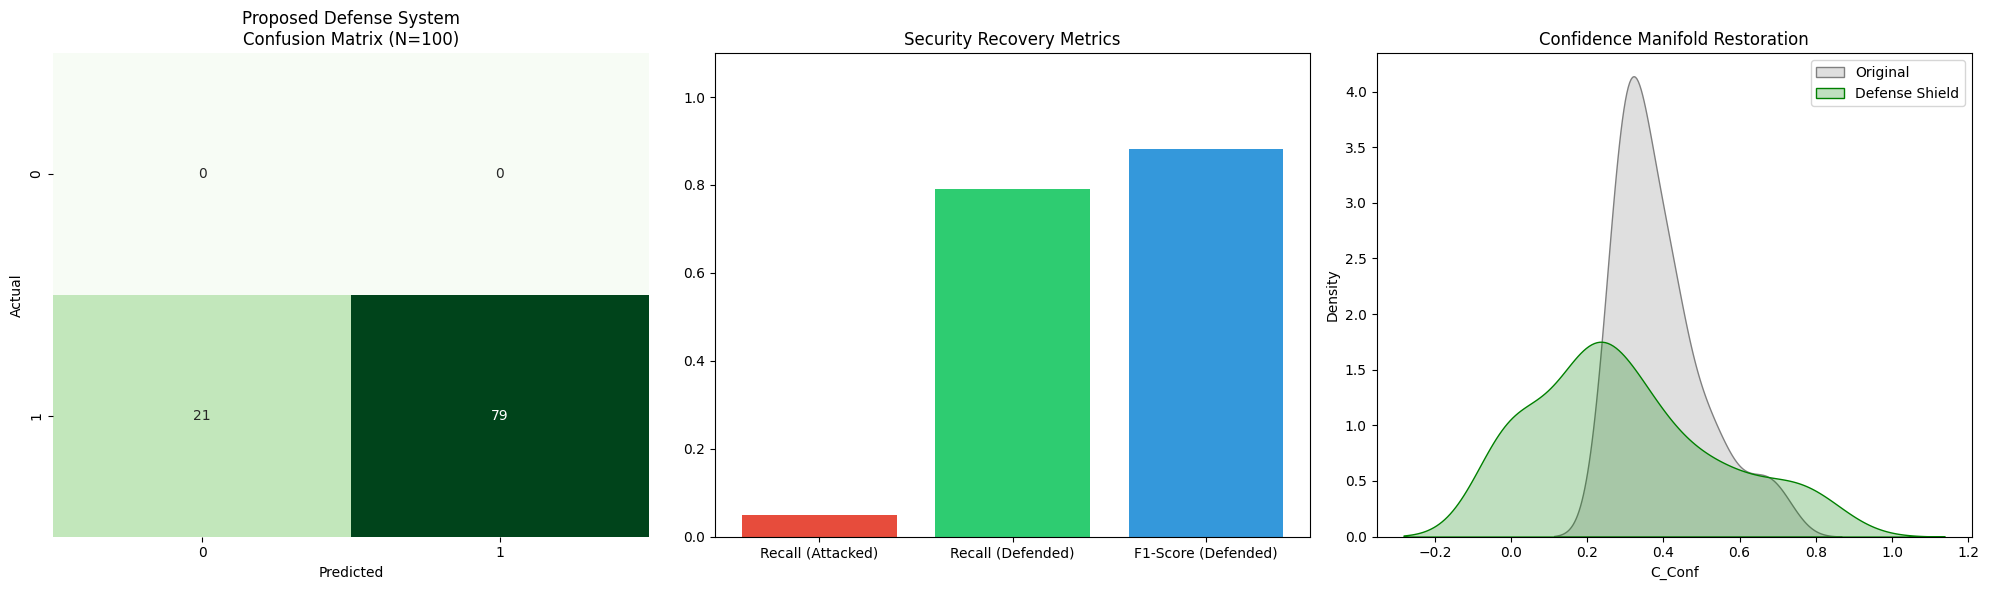


             FINAL QUANTITATIVE EVALUATION             
Total Successful Tests:    100
Attack Success Rate (ASR): 95.00%
Defense Recovery Rate:     79.00%
Final F1-Score:            0.8827
Avg Anomaly Score (SSIM):  0.4924


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.datasets import fetch_lfw_people
from skimage.metrics import structural_similarity as ssim
import cv2

print("[CELL 7] SOTA Benchmarking: Quantitative Security Analysis")

# 1. Load Dataset
print("Loading dataset...")
lfw = fetch_lfw_people(min_faces_per_person=2, resize=1.0)
target_samples = 100  # We WANT 100 successful tests
data_log = []
found_count = 0
current_index = 0

print(f"Searching for {target_samples} valid face samples...")

# Keep looping until we hit our target count or run out of images
while found_count < target_samples and current_index < len(lfw.images):
    # Prepare image
    img_gray = lfw.images[current_index]
    img_uint8 = (img_gray * 255).astype(np.uint8)
    img = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (512, 512))

    # --- PHASE 1: CLEAN (Baseline) ---
    res_c = detector(img, verbose=False)

    # Only proceed if a face is actually detected in the clean image
    if len(res_c[0].boxes) > 0:
        box = res_c[0].boxes.xyxy.cpu().numpy()[0]
        c_conf = float(res_c[0].boxes.conf.cpu().numpy()[0])
        x1, y1, x2, y2 = map(int, box)

        # --- PHASE 2: ATTACKED (Evasion) ---
        atk_img = apply_patch(img, x1, y1, x2-x1, y2-y1)
        res_a = detector(atk_img, verbose=False)
        attack_val = 1 if len(res_a[0].boxes) > 0 else 0
        a_conf = float(res_a[0].boxes.conf.cpu().numpy()[0]) if attack_val == 1 else 0

        # --- PHASE 3: DEFENDED (Proposed Sentinel) ---
        gray_a = cv2.cvtColor(atk_img, cv2.COLOR_RGB2GRAY)
        mask_a = np.where(np.abs(cv2.Laplacian(gray_a, cv2.CV_64F)) > 40, 255, 0).astype(np.uint8)
        neut_a = np.where(cv2.dilate(mask_a, np.ones((15,15)), iterations=2)[:,:,None] == 255,
                          cv2.medianBlur(atk_img, 15), atk_img)

        # GAN Purification
        _, _, pur_a = purifier.enhance(neut_a, has_aligned=False, only_center_face=False)
        res_d = detector(pur_a, conf=0.15, verbose=False)

        defense_val = 1 if len(res_d[0].boxes) > 0 else 0
        d_conf = float(res_d[0].boxes.conf.cpu().numpy()[0]) if defense_val == 1 else 0
        s_score = ssim(img, pur_a, channel_axis=2)

        data_log.append({
            'Clean': 1, 'Attacked': attack_val, 'Defended': defense_val,
            'C_Conf': c_conf, 'A_Conf': a_conf, 'D_Conf': d_conf, 'Anomaly': 1.0 - s_score
        })

        found_count += 1
        if found_count % 10 == 0:
            print(f"Progress: {found_count}/{target_samples} faces found and tested...")

    current_index += 1

# --- 2. GENERATE RESULTS TABLE & GRAPHS ---
df = pd.DataFrame(data_log)
y_true = np.ones(len(df))

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_true, df['Defended'], labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title(f'Proposed Defense System\nConfusion Matrix (N={len(df)})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 3, 2)
atk_recall = recall_score(y_true, df['Attacked'], zero_division=0)
def_recall = recall_score(y_true, df['Defended'], zero_division=0)
def_f1 = f1_score(y_true, df['Defended'], zero_division=0)
plt.bar(['Recall (Attacked)', 'Recall (Defended)', 'F1-Score (Defended)'],
        [atk_recall, def_recall, def_f1], color=['#e74c3c', '#2ecc71', '#3498db'])
plt.ylim(0, 1.1)
plt.title('Security Recovery Metrics')

plt.subplot(1, 3, 3)
sns.kdeplot(df['C_Conf'], label='Original', fill=True, color='gray')
sns.kdeplot(df['D_Conf'], label='Defense Shield', fill=True, color='green')
plt.title('Confidence Manifold Restoration')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("             FINAL QUANTITATIVE EVALUATION             ")
print("="*60)
print(f"Total Successful Tests:    {len(df)}")
print(f"Attack Success Rate (ASR): {(1-atk_recall)*100:.2f}%")
print(f"Defense Recovery Rate:     {def_recall*100:.2f}%")
print(f"Final F1-Score:            {def_f1:.4f}")
print(f"Avg Anomaly Score (SSIM):  {df['Anomaly'].mean():.4f}")
print("="*60)